In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
wego = pd.read_csv(r"C:\Users\Micki\workspace\python\we-go-axle-rose\Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [3]:
wego.dtypes

CALENDAR_ID                    int64
SERVICE_ABBR                   int64
ADHERENCE_ID                   int64
DATE                          object
ROUTE_ABBR                     int64
BLOCK_ABBR                     int64
OPERATOR                       int64
TRIP_ID                        int64
OVERLOAD_ID                    int64
ROUTE_DIRECTION_NAME          object
TIME_POINT_ABBR               object
ROUTE_STOP_SEQUENCE          float64
TRIP_EDGE                      int64
LATITUDE                     float64
LONGITUDE                    float64
SCHEDULED_TIME                object
ACTUAL_ARRIVAL_TIME           object
ACTUAL_DEPARTURE_TIME         object
ADHERENCE                    float64
SCHEDULED_HDWY               float64
ACTUAL_HDWY                  float64
HDWY_DEV                     float64
ADJUSTED_EARLY_COUNT           int64
ADJUSTED_LATE_COUNT            int64
ADJUSTED_ONTIME_COUNT          int64
STOP_CANCELLED                 int64
PREV_SCHED_STOP_CANCELLED    float64
I

### 1. What is the overall on-time performance, and what do the overall distribution of adherence look like? 


In [4]:
print(wego['ADJUSTED_ONTIME_COUNT'].sum())
print(wego['ADJUSTED_LATE_COUNT'].sum())
print(wego['ADJUSTED_EARLY_COUNT'].sum())

270048
59038
9775


In [5]:
total = wego['ADJUSTED_ONTIME_COUNT'].sum() + wego['ADJUSTED_LATE_COUNT'].sum() + wego['ADJUSTED_EARLY_COUNT'].sum()

print(f'Total: {total}')
print(f'On Time: {270048/total*100:.1f}%')
print(f'Late: {59038/total*100:.1f}%')
print(f'Early: {9775/total*100:.1f}%')

Total: 338861
On Time: 79.7%
Late: 17.4%
Early: 2.9%


#### WeGo's overall on-time performance is 79.7% — meaning about 4 out of every 5 timepoint crossings are on time.

In [6]:
# stat summary
wego['ADHERENCE'].describe()

count    338861.000000
mean         -3.188796
std           6.898842
min        -948.533333
25%          -4.566666
50%          -2.000000
75%          -0.333333
max          88.383333
Name: ADHERENCE, dtype: float64

In [7]:
# count rows which are +60mins late or early
print(wego[wego['ADHERENCE'] < -60].shape[0])
print(wego[wego['ADHERENCE'] > 60].shape[0])

303
30


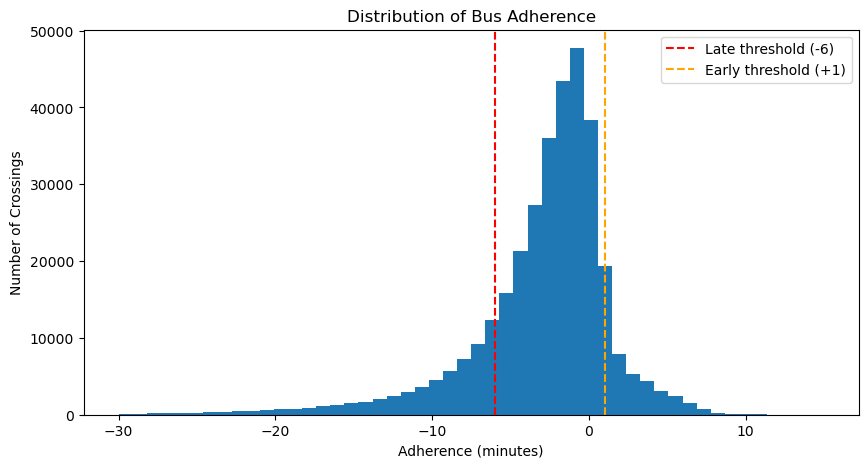

In [8]:
import matplotlib.pyplot as plt

adherence_filtered = wego[(wego['ADHERENCE'] > -30) & (wego['ADHERENCE'] < 15)]

plt.figure(figsize=(10, 5))
plt.hist(adherence_filtered['ADHERENCE'], bins=50)
plt.axvline(x=-6, color='red', linestyle='--', label='Late threshold (-6)')
plt.axvline(x=1, color='orange', linestyle='--', label='Early threshold (+1)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Crossings')
plt.title('Distribution of Bus Adherence')
plt.legend()
plt.show()

#### The majority of the data falls between the two threshold lines (between -6 and +1), which is consistent with the 79.7% on-time figure

---


### 2. How does direction of travel, route, or location affect the on-time performance?

In [9]:
wego.groupby('ROUTE_DIRECTION_NAME')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT
ROUTE_DIRECTION_NAME,,,
FROM DOWNTOWN,134414,39601,5291
TO DOWNTOWN,135634,19437,4484


In [10]:
from_total = 134414 + 39601 + 5291


print(f"FROM DOWNTOWN On Time: {134414/from_total*100:.1f}%")
print(f"FROM DOWNTOWN Late: {39601/from_total*100:.1f}%")
print(f"FROM DOWNTOWN Early: {5291/from_total*100:.1f}%")

FROM DOWNTOWN On Time: 75.0%
FROM DOWNTOWN Late: 22.1%
FROM DOWNTOWN Early: 3.0%


In [11]:
to_total = 135634 + 19437 + 4484

print(f"TO DOWNTOWN On Time: {135634/from_total*100:.1f}%")
print(f"TO DOWNTOWN Late: {19437/from_total*100:.1f}%")
print(f"TO DOWNTOWN Early: {4484/from_total*100:.1f}%")

TO DOWNTOWN On Time: 75.6%
TO DOWNTOWN Late: 10.8%
TO DOWNTOWN Early: 2.5%


#### The difference is pretty small for on-time (75.0% vs 75.6%), but the late numbers differ. FROM DOWNTOWN is 22.1% late compared to only 10.8% late for TO DOWNTOWN

In [12]:
# rank the routes based on worst on-time performance
route_performance = wego.groupby('ROUTE_ABBR')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

route_performance['total'] = route_performance['ADJUSTED_ONTIME_COUNT'] + route_performance['ADJUSTED_LATE_COUNT'] + route_performance['ADJUSTED_EARLY_COUNT']

route_performance['pct_late'] = route_performance['ADJUSTED_LATE_COUNT'] / route_performance['total'] * 100

route_performance.sort_values('pct_late', ascending=False).head(10)

,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT,total,pct_late
ROUTE_ABBR,,,,,
55,42080,16748,1531,60359,27.747312
3,34516,9590,1382,45488,21.082483
52,37736,10038,1553,49327,20.349910
7,13417,3417,433,17267,19.789193
56,48361,8837,1752,58950,14.990670
50,36309,5113,1207,42629,11.994182
22,22492,2065,631,25188,8.198348
23,35137,3230,1286,39653,8.145664


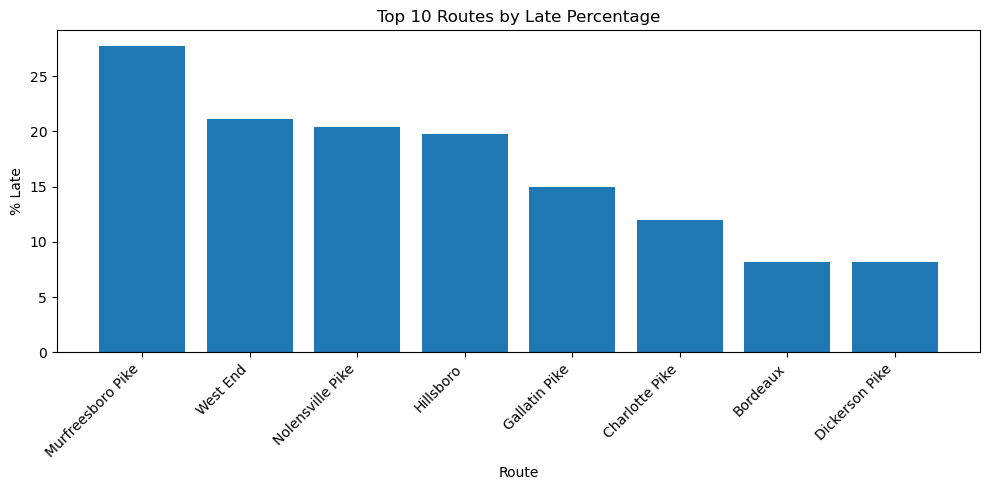

In [13]:
route_names = {
    3: 'West End',
    7: 'Hillsboro',
    22: 'Bordeaux',
    23: 'Dickerson Pike',
    50: 'Charlotte Pike',
    52: 'Nolensville Pike',
    55: 'Murfreesboro Pike',
    56: 'Gallatin Pike'
}

top10_late = route_performance.sort_values('pct_late', ascending=False).head(10)
labels = [route_names.get(r, f'Route {r}') for r in top10_late.index]

plt.figure(figsize=(10, 5))
plt.bar(labels, top10_late['pct_late'])
plt.xlabel('Route')
plt.ylabel('% Late')
plt.title('Top 10 Routes by Late Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# location data
stop_performance = wego.groupby('TIME_POINT_ABBR')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

stop_performance['total'] = stop_performance['ADJUSTED_ONTIME_COUNT'] + stop_performance['ADJUSTED_LATE_COUNT'] + stop_performance['ADJUSTED_EARLY_COUNT']

stop_performance['pct_late'] = stop_performance['ADJUSTED_LATE_COUNT'] / stop_performance['total'] * 100

stop_performance.sort_values('pct_late', ascending=False).head(10)

,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT,total,pct_late
TIME_POINT_ABBR,,,,,
MCC5_7,2,31,3,36,86.111111
MCC5_11,21,49,0,70,70.000000
MCC5_12,16,23,0,39,58.974359
MCC4_20,55,43,1,99,43.434343
DCSCC,1021,699,125,1845,37.886179
MXDONEL,6320,3338,277,9935,33.598390
MCC4_22,53,34,15,102,33.333333
MXWHARF,6578,3218,319,10115,31.814137
SAMS,3171,1509,167,4847,31.132659


In [15]:
stop_performance_filtered = stop_performance[stop_performance['total'] >= 500]
stop_performance_filtered.sort_values('pct_late', ascending=False).head(10)


,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT,total,pct_late
TIME_POINT_ABBR,,,,,
DCSCC,1021,699,125,1845,37.886179
MXDONEL,6320,3338,277,9935,33.598390
MXWHARF,6578,3218,319,10115,31.814137
SAMS,3171,1509,167,4847,31.132659
MXBELL,6773,2949,201,9923,29.718835
MXTHOMP,6957,2578,567,10102,25.519699
YGKG,1522,486,13,2021,24.047501
21BK,4293,1413,189,5895,23.969466
HDANT,3061,975,63,4099,23.786289


In [16]:
stop_coords = wego.groupby('TIME_POINT_ABBR')[['LATITUDE', 'LONGITUDE']].mean()

stop_performance_filtered = stop_performance_filtered.join(stop_coords)

stop_performance_filtered.sort_values('pct_late', ascending=False).head(10)

,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT,total,pct_late,LATITUDE,LONGITUDE
TIME_POINT_ABBR,,,,,,,
DCSCC,1021,699,125,1845,37.886179,36.086817,-86.686874
MXDONEL,6320,3338,277,9935,33.598390,36.105945,-86.672402
MXWHARF,6578,3218,319,10115,31.814137,36.148850,-86.762464
SAMS,3171,1509,167,4847,31.132659,36.307973,-86.685963
MXBELL,6773,2949,201,9923,29.718835,36.072420,-86.636679
MXTHOMP,6957,2578,567,10102,25.519699,36.127660,-86.712306
YGKG,1522,486,13,2021,24.047501,36.203239,-86.840636
21BK,4293,1413,189,5895,23.969466,36.138631,-86.800622
HDANT,3061,975,63,4099,23.786289,36.087288,-86.692935


In [17]:
!pip install folium

In [18]:
import folium

In [19]:
nashville_map = folium.Map(location=[36.1627, -86.7816], zoom_start=12)

top_stops = stop_performance_filtered.sort_values('pct_late', ascending=False).head(20)

for stop, row in top_stops.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=row['pct_late'] / 2,
        color='red',
        fill=True,
        popup=f"{stop}: {row['pct_late']:.1f}% late"
    ).add_to(nashville_map)

nashville_map

#### The biggest circles equal the worst late percentages, which are clustered around downtown Nashville and just south of it (Murfreesboro Pike) There's a notable cluster of large circles in the downtown core where multiple routes converge. The stops further out from downtown tend to have smaller circles, suggesting better on-time performance at the outer edges of routes. That big circle up north near Goodlettsville is an interesting outlier.
---

### 3. How does time of day or day of week affect on-time performance?


In [20]:
wego['SCHEDULED_TIME'] = pd.to_datetime(wego['SCHEDULED_TIME'])
wego['HOUR'] = wego['SCHEDULED_TIME'].dt.hour

In [21]:
wego['HOUR'].value_counts().sort_index()

HOUR
0      4221
1       123
4      1724
5     10466
6     19980
7     22732
8     21273
9     20815
10    20489
11    20418
12    20710
13    20558
14    21154
15    22855
16    22657
17    21762
18    18049
19    14060
20    12801
21    12338
22    11643
23     9501
Name: count, dtype: int64

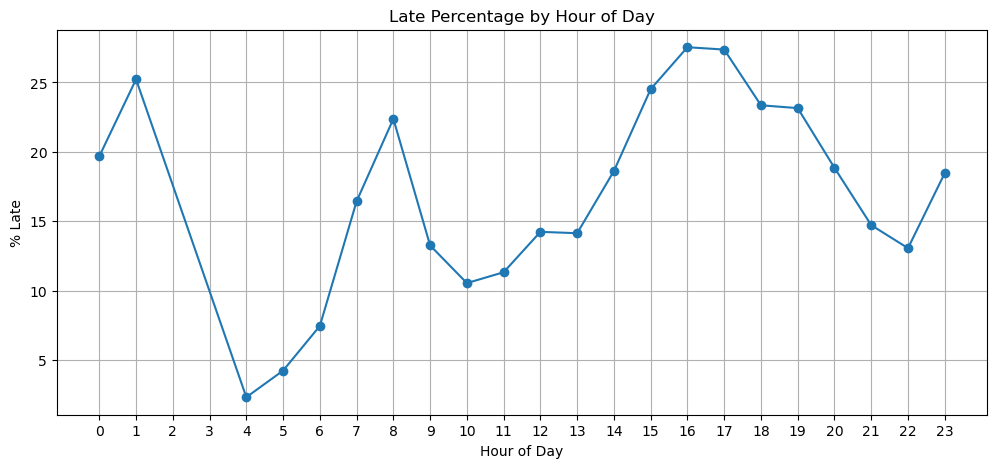

In [22]:
# calculate late percent by hour

hour_performance = wego.groupby('HOUR')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

hour_performance['total'] = hour_performance['ADJUSTED_ONTIME_COUNT'] + hour_performance['ADJUSTED_LATE_COUNT'] + hour_performance['ADJUSTED_EARLY_COUNT']

hour_performance['pct_late'] = hour_performance['ADJUSTED_LATE_COUNT'] / hour_performance['total'] * 100

plt.figure(figsize=(12, 5))
plt.plot(hour_performance.index, hour_performance['pct_late'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('% Late')
plt.title('Late Percentage by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

#### Early morning (4-5am) is best, afternoon rush hour (4-5pm) is worst at nearly 28% late, with a smaller morning rush spike around 7-8am

In [23]:
# look at day of week 

day_performance = wego.groupby('SERVICE_ABBR')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

day_performance['total'] = day_performance['ADJUSTED_ONTIME_COUNT'] + day_performance['ADJUSTED_LATE_COUNT'] + day_performance['ADJUSTED_EARLY_COUNT']

day_performance['pct_late'] = day_performance['ADJUSTED_LATE_COUNT'] / day_performance['total'] * 100

day_performance

,ADJUSTED_ONTIME_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_EARLY_COUNT,total,pct_late
SERVICE_ABBR,,,,,
1,213690,48629,7968,270287,17.991616
2,28962,6747,821,36530,18.469751
3,27396,3662,986,32044,11.428036


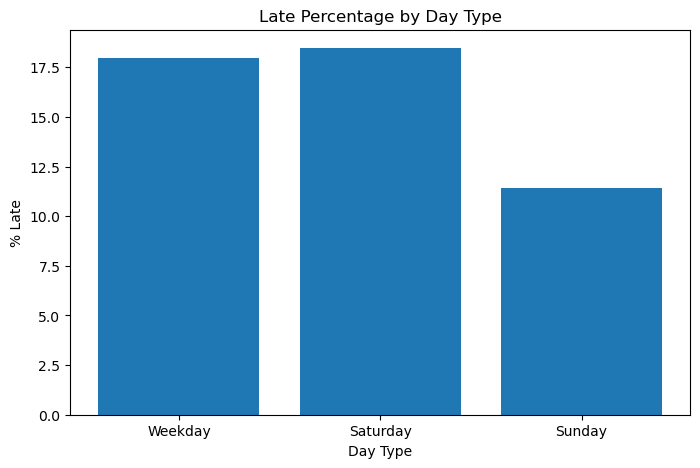

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(['Weekday', 'Saturday', 'Sunday'], day_performance['pct_late'])
plt.xlabel('Day Type')
plt.ylabel('% Late')
plt.title('Late Percentage by Day Type')
plt.show()

#### Sundays are significantly better (11.4% late) while weekdays and Saturdays are similar (~18%)
---

### 4. How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.


In [25]:
print(f"Total unique drivers: {wego['OPERATOR'].nunique()}")

Total unique drivers: 341


In [26]:
driver_performance = wego.groupby('OPERATOR')[['ADJUSTED_ONTIME_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_EARLY_COUNT']].sum()

driver_performance['total'] = driver_performance['ADJUSTED_ONTIME_COUNT'] + driver_performance['ADJUSTED_LATE_COUNT'] + driver_performance['ADJUSTED_EARLY_COUNT']

driver_performance['pct_late'] = driver_performance['ADJUSTED_LATE_COUNT'] / driver_performance['total'] * 100

driver_performance_filtered = driver_performance[driver_performance['total'] >= 500]

print(f"Drivers with 500+ crossings: {len(driver_performance_filtered)}")
driver_performance_filtered['pct_late'].describe()

Drivers with 500+ crossings: 239


count    239.000000
mean      18.054919
std       11.620994
min        0.612341
25%        9.937287
50%       15.944700
75%       23.831800
max       54.420732
Name: pct_late, dtype: float64

#### Average late rate: 18% — consistent with our overall numbers; Min: 0.6% — somebody is almost never late!; Max: 54.4% — somebody is late more than half the time!; The middle 50% of drivers fall between 9.9% and 23.8% late.

#### That strongly suggests that the individual driver does matter, not just the route and traffic conditions.

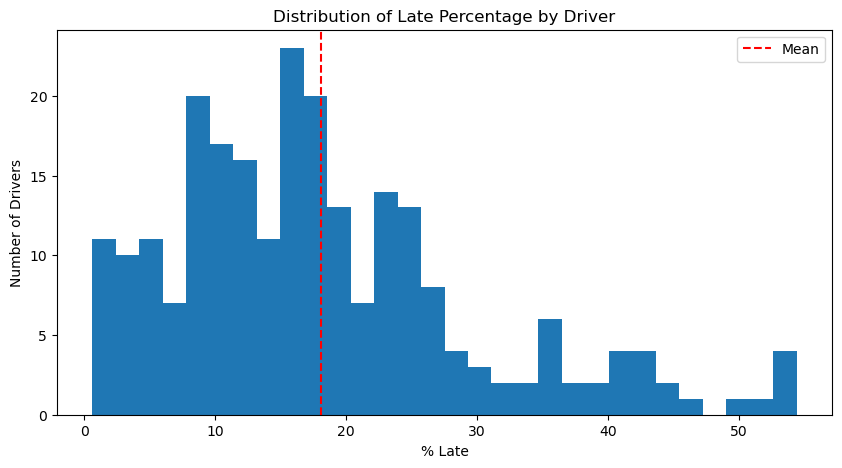

In [27]:
# histogram of how drivers are distributed around the average late percentage
plt.figure(figsize=(10, 5))
plt.hist(driver_performance_filtered['pct_late'], bins=30)
plt.axvline(x=driver_performance_filtered['pct_late'].mean(), 
            color='red', linestyle='--', label='Mean')
plt.xlabel('% Late')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Late Percentage by Driver')
plt.legend()
plt.show()

#### There's a cluster of drivers on the left side (0-10%) who are genuinely excellent performers; The bulk of drivers fall between 10-25% late, around the mean; There's a long tail to the right — a smaller group of drivers who are consistently much worse than average, some approaching 55% late; The distribution is skewed right, meaning there are more outlier bad performers than outlier good performers.

#### If lateness were purely about routes and traffic, you'd expect all drivers on the same route to perform similarly. The widespread suggests individual driver skill and experience genuinely matter
---

### 5. Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.


In [28]:
# filter outlier to useable range
q5_data = wego[
    (wego['ADHERENCE'] > -30) & 
    (wego['ADHERENCE'] < 15) & 
    (wego['HDWY_DEV'].notna()) &
    (wego['HDWY_DEV'] > -60) & 
    (wego['HDWY_DEV'] < 60)
]

print(q5_data.shape)

(264313, 31)


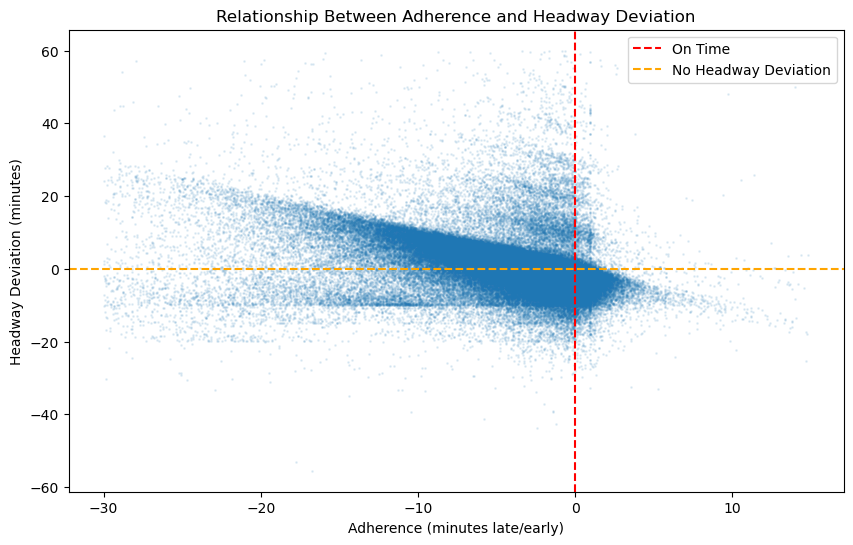

In [29]:
#scatterplot of adherence

plt.figure(figsize=(10, 6))
plt.scatter(q5_data['ADHERENCE'], q5_data['HDWY_DEV'], alpha=0.1, s=1)
plt.axvline(x=0, color='red', linestyle='--', label='On Time')
plt.axhline(y=0, color='orange', linestyle='--', label='No Headway Deviation')
plt.xlabel('Adherence (minutes late/early)')
plt.ylabel('Headway Deviation (minutes)')
plt.title('Relationship Between Adherence and Headway Deviation')
plt.legend()
plt.show()

#### The densest cluster of dots is right around (0, 0) — meaning most buses are on time with normal headway. As buses get more late (moving left on the x-axis), the headway deviation fans out both up and down. The bottom left quadrant (late AND bunching) has a lot of dots, meaning later buses, more bunching. But interestingly, the top-left quadrant (late AND gapping) also has a lot of dots — meaning that when one bus is very late, the bus behind it sometimes gaps because passengers gave up and took the late bus.

In [30]:
correlation = q5_data['ADHERENCE'].corr(q5_data['HDWY_DEV'])
print(f"Correlation between Adherence and Headway Deviation: {correlation:.3f}")

Correlation between Adherence and Headway Deviation: -0.364


#### As adherence goes down (more buses are late), headway deviation also tends to go down (more bunching due to late buses). 
---

### 6. How much impact does being late or too spaced out at the first stop have downstream?  


In [32]:
# first stops of each trip
first_stops = wego[wego['TRIP_EDGE'] == 1][['CALENDAR_ID', 'TRIP_ID', 'ADHERENCE']].copy()
first_stops = first_stops.rename(columns={'ADHERENCE': 'FIRST_STOP_ADHERENCE'})

print(first_stops.shape)
print(first_stops.head())

(67416, 3)
    CALENDAR_ID  TRIP_ID  FIRST_STOP_ADHERENCE
0     120230801   345104             -2.133333
4     120230801   345105             -1.583333
7     120230801   345106             -1.716666
11    120230801   345107             -1.316666
14    120230801   345108             -1.516666


In [33]:
# downstream stops joined with first stops

downstream_stops = wego[wego['TRIP_EDGE'] != 1][['CALENDAR_ID', 'TRIP_ID', 'ADHERENCE', 'ROUTE_STOP_SEQUENCE']].copy()

trip_comparison = downstream_stops.merge(first_stops, on=['CALENDAR_ID', 'TRIP_ID'], how='inner')

print(trip_comparison.shape)
print(trip_comparison.head())

(283268, 5)
   CALENDAR_ID  TRIP_ID  ADHERENCE  ROUTE_STOP_SEQUENCE  FIRST_STOP_ADHERENCE
0    120230801   345104  -2.450000                 10.0             -2.133333
1    120230801   345104  -0.933333                  5.0             -2.133333
2    120230801   345104   6.283333                  1.0             -2.133333
3    120230801   345105   0.950000                  5.0             -1.583333
4    120230801   345105   1.500000                 14.0             -1.583333


In [34]:
# buckets showing late trips in the beginning and how they preformed on average

def categorize_start(adherence):
    if adherence < -6:
        return '3. Very Late Start (>6 min)'
    elif adherence < 0:
        return '2. Slightly Late Start (0-6 min)'
    else:
        return '1. On Time or Early Start'

trip_comparison['START_CATEGORY'] = trip_comparison['FIRST_STOP_ADHERENCE'].apply(categorize_start)

trip_comparison.groupby('START_CATEGORY')['ADHERENCE'].mean()

START_CATEGORY
1. On Time or Early Start           -2.398502
2. Slightly Late Start (0-6 min)    -2.413794
3. Very Late Start (>6 min)        -11.429973
Name: ADHERENCE, dtype: float64

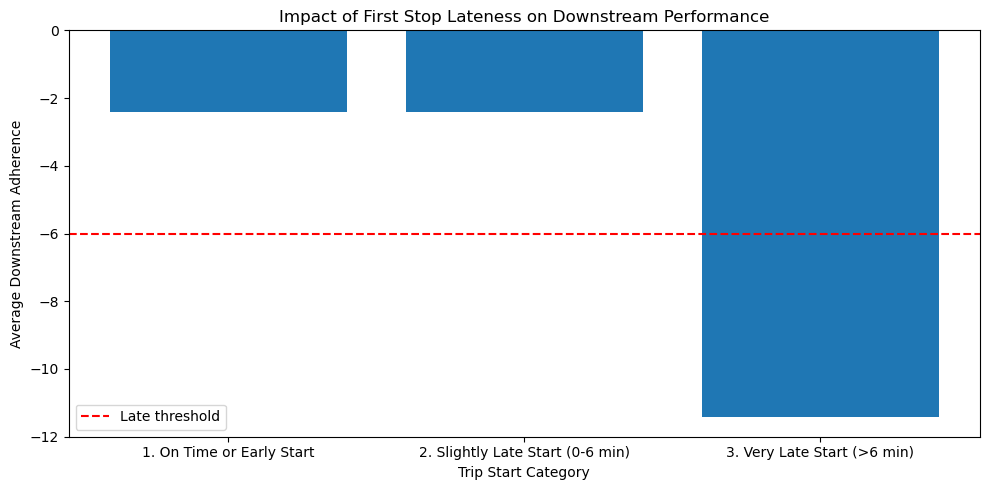

In [35]:
# barchart to visualize results
start_impact = trip_comparison.groupby('START_CATEGORY')['ADHERENCE'].mean()

plt.figure(figsize=(10, 5))
plt.bar(start_impact.index, start_impact.values)
plt.axhline(y=-6, color='red', linestyle='--', label='Late threshold')
plt.xlabel('Trip Start Category')
plt.ylabel('Average Downstream Adherence')
plt.title('Impact of First Stop Lateness on Downstream Performance')
plt.legend()
plt.tight_layout()
plt.show()

#### Buses that start slightly late actually recover pretty well — their downstream performance is almost identical to buses that started on time. Once a bus is more than 6 minutes late at the first stop, it really struggles to recover.
---

### 7. What is the impact of the layover at the start of the trip (the difference between the first stop arrival and departure time)? Does more dwell time at the beginning of a trip lead to more stable headways (lower values for % headway deviation)? Do trips with longer **scheduled** layover time have more stable headway values?  


In [36]:
# filtering to first stops only; removing where layover is null

layover_trips = wego[
    (wego['TRIP_EDGE'] == 1) & 
    (wego['SCHEDULED_LAYOVER_MINUTES'].notna()) &
    (wego['DWELL_IN_MINS'].notna())
][['CALENDAR_ID', 'TRIP_ID', 'SCHEDULED_LAYOVER_MINUTES', 'DWELL_IN_MINS']]

print(layover_trips.shape)
print(layover_trips.describe())

(53093, 4)
        CALENDAR_ID        TRIP_ID  SCHEDULED_LAYOVER_MINUTES  DWELL_IN_MINS
count  5.309300e+04   53093.000000               53093.000000   53093.000000
mean   1.202309e+08  351543.925414                  12.629198      13.994257
std    5.067297e+01    1556.528343                   6.393644      10.261605
min    1.202308e+08  345105.000000                   0.000000    -208.033333
25%    1.202308e+08  350489.000000                  10.000000       9.400000
50%    1.202308e+08  351935.000000                  10.000000      13.350000
75%    1.202309e+08  352681.000000                  16.000000      17.500000
max    1.202309e+08  353533.000000                 118.000000     956.500000


In [37]:
# reviewing large time gaps from above query; capping dwell at 2hrs and layovers at 1hr
layover_trips = layover_trips[
    (layover_trips['DWELL_IN_MINS'] >= 0) &
    (layover_trips['DWELL_IN_MINS'] < 120) &
    (layover_trips['SCHEDULED_LAYOVER_MINUTES'] < 60)
]

print(layover_trips.shape)

(53077, 4)


In [38]:
#joining data with headway deviation

downstream_hdwy = wego[
    (wego['TRIP_EDGE'] != 1) & 
    (wego['HDWY_DEV'].notna())
][['CALENDAR_ID', 'TRIP_ID', 'HDWY_DEV']]

layover_analysis = layover_trips.merge(downstream_hdwy, on=['CALENDAR_ID', 'TRIP_ID'], how='inner')

print(layover_analysis.shape)
print(layover_analysis.head())

(165094, 5)
   CALENDAR_ID  TRIP_ID  SCHEDULED_LAYOVER_MINUTES  DWELL_IN_MINS  HDWY_DEV
0    120230801   345106                       10.0      13.216666  1.966666
1    120230801   345106                       10.0      13.216666 -0.483334
2    120230801   345107                        5.0      10.800000 -3.883334
3    120230801   345108                        7.0      12.533333  0.083333
4    120230801   345108                        7.0      12.533333  2.716666


In [39]:
# categorize trips by layover time
def categorize_layover(minutes):
    if minutes < 5:
        return '1. Short (<5 min)'
    elif minutes < 10:
        return '2. Medium (5-10 min)'
    elif minutes < 20:
        return '3. Long (10-20 min)'
    else:
        return '4. Very Long (20+ min)'

layover_analysis['LAYOVER_CATEGORY'] = layover_analysis['SCHEDULED_LAYOVER_MINUTES'].apply(categorize_layover)

layover_analysis['ABS_HDWY_DEV'] = layover_analysis['HDWY_DEV'].abs()

layover_analysis.groupby('LAYOVER_CATEGORY')['ABS_HDWY_DEV'].mean()

LAYOVER_CATEGORY
1. Short (<5 min)         3.289280
2. Medium (5-10 min)      3.990093
3. Long (10-20 min)       4.212591
4. Very Long (20+ min)    3.611937
Name: ABS_HDWY_DEV, dtype: float64

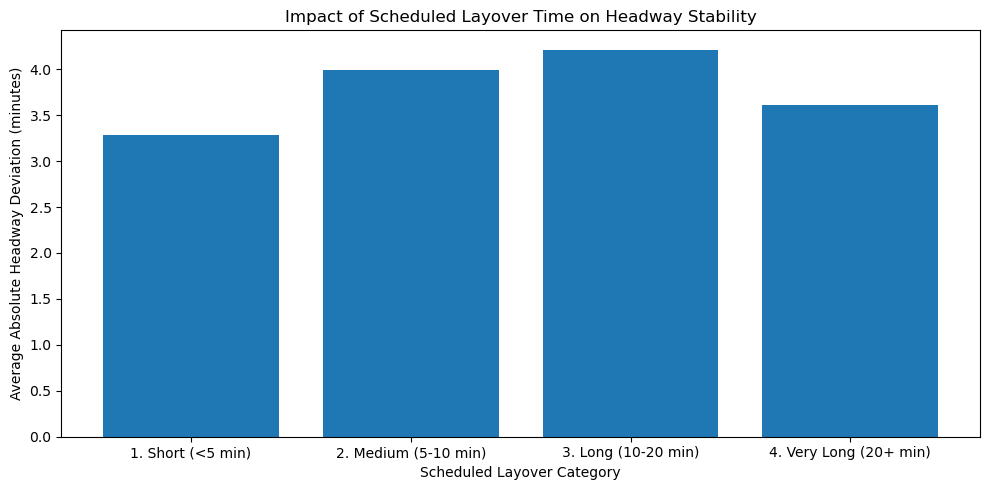

In [40]:
#visualize data with barchart

layover_impact = layover_analysis.groupby('LAYOVER_CATEGORY')['ABS_HDWY_DEV'].mean()

plt.figure(figsize=(10, 5))
plt.bar(layover_impact.index, layover_impact.values)
plt.xlabel('Scheduled Layover Category')
plt.ylabel('Average Absolute Headway Deviation (minutes)')
plt.title('Impact of Scheduled Layover Time on Headway Stability')
plt.tight_layout()
plt.show()

In [41]:
#actual dwell time vs headway stability
layover_analysis['DWELL_CATEGORY'] = layover_analysis['DWELL_IN_MINS'].apply(categorize_layover)

layover_analysis.groupby('DWELL_CATEGORY')['ABS_HDWY_DEV'].mean()

DWELL_CATEGORY
1. Short (<5 min)         5.626407
2. Medium (5-10 min)      4.607650
3. Long (10-20 min)       3.815993
4. Very Long (20+ min)    3.645960
Name: ABS_HDWY_DEV, dtype: float64

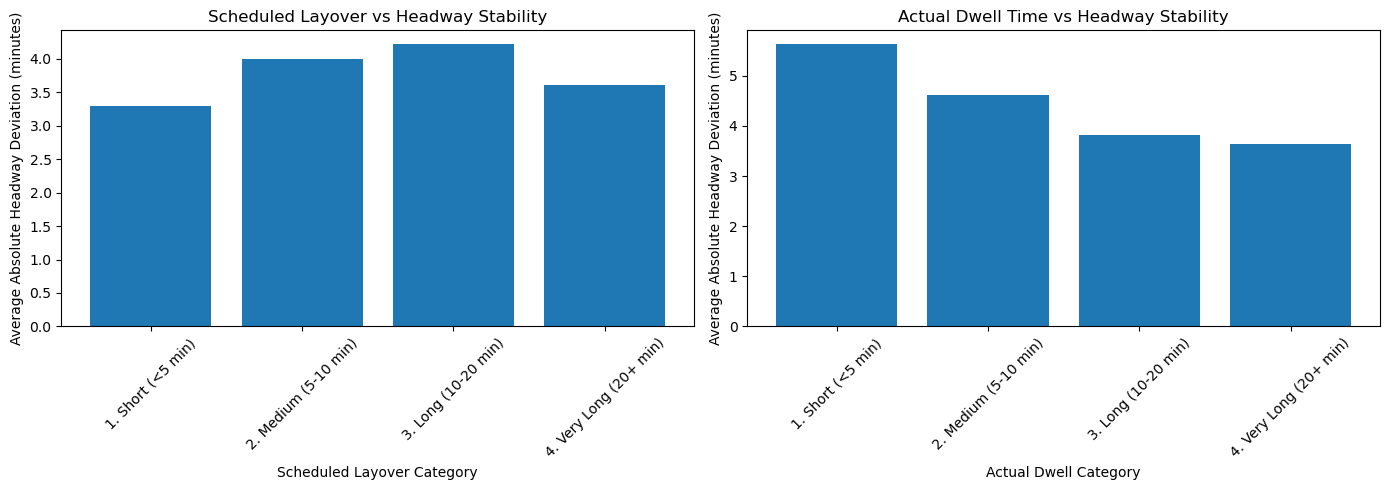

In [42]:
#visual of both scheduled and dwell impacts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

scheduled_impact = layover_analysis.groupby('LAYOVER_CATEGORY')['ABS_HDWY_DEV'].mean()
ax1.bar(scheduled_impact.index, scheduled_impact.values)
ax1.set_xlabel('Scheduled Layover Category')
ax1.set_ylabel('Average Absolute Headway Deviation (minutes)')
ax1.set_title('Scheduled Layover vs Headway Stability')
ax1.tick_params(axis='x', rotation=45)

dwell_impact = layover_analysis.groupby('DWELL_CATEGORY')['ABS_HDWY_DEV'].mean()
ax2.bar(dwell_impact.index, dwell_impact.values)
ax2.set_xlabel('Actual Dwell Category')
ax2.set_ylabel('Average Absolute Headway Deviation (minutes)')
ax2.set_title('Actual Dwell Time vs Headway Stability')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### The results suggest that encouraging drivers to take their full layover time rather than rushing out early could meaningfully improve headway stability downstream. The schedule isn't what matters; it's whether drivers actually use that time. 
---

### 8. What is the relationship between distance or time traveled since the start of a given trip and the adherence value? Does on-time performance become less stable the further along the route the bus has traveled?


In [44]:
# describe the data in route stop seq
print(wego['ROUTE_STOP_SEQUENCE'].describe())

count    350318.000000
mean          7.351284
std           4.033002
min           1.000000
25%           4.000000
50%           6.000000
75%          10.000000
max          17.000000
Name: ROUTE_STOP_SEQUENCE, dtype: float64


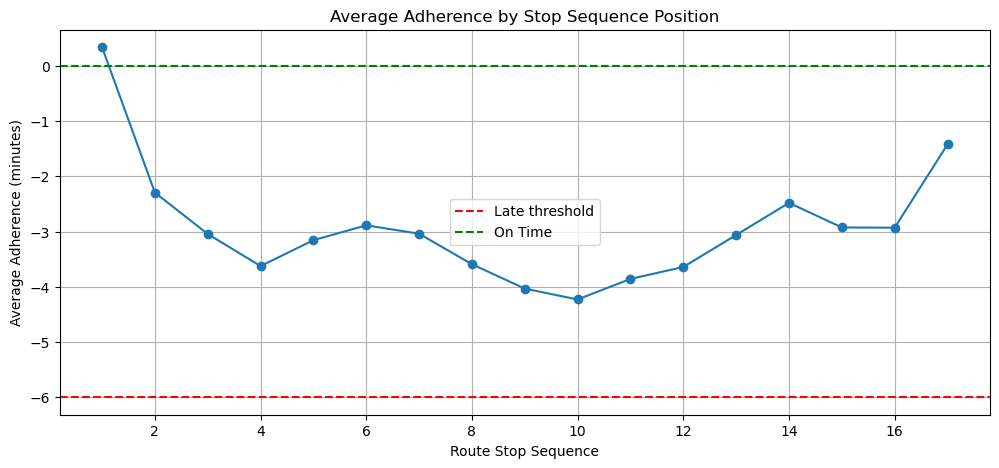

In [45]:
# calculate the average adherence at each stop position
stop_sequence_performance = wego[wego['ADHERENCE'].notna()].groupby('ROUTE_STOP_SEQUENCE')['ADHERENCE'].mean()

plt.figure(figsize=(12, 5))
plt.plot(stop_sequence_performance.index, stop_sequence_performance.values, marker='o')
plt.axhline(y=-6, color='red', linestyle='--', label='Late threshold')
plt.axhline(y=0, color='green', linestyle='--', label='On Time')
plt.xlabel('Route Stop Sequence')
plt.ylabel('Average Adherence (minutes)')
plt.title('Average Adherence by Stop Sequence Position')
plt.legend()
plt.grid(True)
plt.show()